In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import scipy.stats as stats
import arviz as az

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

from gurobipy import *
import pytensor.tensor as pt

import joblib


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


## Get player details


In [ ]:
players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_36.csv', index_col=0)
fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_24_25.csv')

# Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')
players_preds.dropna(subset=['FPL_ID'], inplace=True)

players_preds = players_preds.drop(['event', 'understat_name', 'fpl_name', 'FPL_ID','FPL_Name', 'team', 'xG_preds', 'xA_preds', 'cs_preds', 'y_preds', 'saves_preds', 'xgc_preds', 'h_team', 'a_team','was_home'], axis=1)
player_cols = players_preds.columns.tolist()

In [6]:
gw=35
data_22_23 = pd.read_csv('../FPL predictors/with new features/data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('../FPL predictors/with new features/data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('../FPL predictors/with new features/data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])

data_cols = player_cols.copy()
data_cols.pop(data_cols.index('xP_preds'))
data_cols.pop(data_cols.index('player_team'))

joblib.dump(data_cols, './data_cols')

data_ = data[data_cols]
gk_data = data[data['position'] == 'GK'][data_cols]
def_data = data[data['position'] == 'DEF'][data_cols]
mid_data = data[data['position'] == 'MID'][data_cols]
fwd_data = data[data['position'] == 'FWD'][data_cols]

gk_data = gk_data.select_dtypes(include=[np.number])
gk_data = gk_data.dropna()
gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

def_data = def_data.select_dtypes(include=[np.number])
def_data = def_data.dropna()
def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

mid_data = mid_data.select_dtypes(include=[np.number])
mid_data = mid_data.dropna()
mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

fwd_data = fwd_data.select_dtypes(include=[np.number])
fwd_data = fwd_data.dropna()
fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

In [8]:

X_def = def_data  # shape: (n_defenders, n_features)

# 1. Standardize (PCA works best on standardized data)
scaler_gk = StandardScaler(with_mean=True, with_std=True)
scaler_def = StandardScaler(with_mean=True, with_std=True)
scaler_mid = StandardScaler(with_mean=True, with_std=True)
scaler_fwd = StandardScaler(with_mean=True, with_std=True)

X_gk = scaler_gk.fit_transform(gk_data.values)
X_def = scaler_def.fit_transform(def_data.values)
X_mid = scaler_mid.fit_transform(mid_data.values)
X_fwd = scaler_fwd.fit_transform(fwd_data.values)

# save standardscaler model
joblib.dump(scaler_gk, "scaler_gk.pkl")
joblib.dump(scaler_def, "scaler_def.pkl")
joblib.dump(scaler_mid, "scaler_mid.pkl")
joblib.dump(scaler_fwd, "scaler_fwd.pkl")


# 2. Choose # of components or variance threshold
pca_gk = PCA(n_components=0.95)  # 0.95 = keep enough PCs to explain 95% of variance
pca_def = PCA(n_components=0.95)
pca_mid = PCA(n_components=0.95)
pca_fwd = PCA(n_components=0.95)

# 3. Fit PCA and transform
X_gk_pca = pd.DataFrame(pca_gk.fit_transform(X_gk))
X_def_pca = pd.DataFrame(pca_def.fit_transform(X_def))
X_mid_pca = pd.DataFrame(pca_mid.fit_transform(X_mid))
X_fwd_pca = pd.DataFrame(pca_fwd.fit_transform(X_fwd))

# save pca mode;
joblib.dump(pca_gk, "pca_gk.pkl")
joblib.dump(pca_def, "pca_def.pkl")
joblib.dump(pca_mid, "pca_mid.pkl")
joblib.dump(pca_fwd, "pca_fwd.pkl")

print("Original shape:", X_gk.shape, X_def.shape, X_mid.shape, X_fwd.shape)
print("Reduced shape:", X_gk_pca.shape, X_def_pca.shape, X_mid_pca.shape, X_fwd_pca.shape)

Original shape: (501, 168) (2387, 168) (3823, 168) (863, 168)
Reduced shape: (501, 57) (2387, 61) (3823, 61) (863, 59)


## Simulate selection probs


In [ ]:
def simulate_observed_probs(X: pd.DataFrame):
    X = X.fillna(0)
    np.random.seed(42)
    num_features = X.shape[1]
    true_beta = np.random.uniform(-0.5, 0.5, size=(num_features,))
    logits = X @ true_beta
    probs = np.exp(logits)
    probs /= probs.sum()
    return probs

# simulate_observed_probs(X_gk_pca)

### Get betas


In [ ]:
def dirichlet_regression_beta_auto(data: pd.DataFrame):
    """
    Perform Bayesian Dirichlet Regression.
    If no observed_probs are given, simulate them based on features.
    """
    if not isinstance(data, pd.DataFrame):
        raise ValueError("Data must be a pandas DataFrame.")

    if data.isnull().any().any():
        raise ValueError("Data contains NaN values. Please clean it first.")

    num_players, num_features = data.shape
    print(f"Number of Players: {num_players}, Number of Features: {num_features}")

    X = data.to_numpy(dtype=np.float64)
    # X = X.fillna(0)

    # --- Simulate observed probabilities ---
    observed_probs = simulate_observed_probs(data)

    with pm.Model() as model:
        # Wide normal prior
        beta = pm.Normal("beta", mu=0, sigma=10, shape=(num_features,))

        eta = pm.math.dot(X, beta)
        alpha = pm.math.exp(eta)

        pm.Dirichlet("obs", a=alpha, observed=observed_probs)

        trace = pm.sample(
            draws=2000,
            # tune=50,
            target_accept=0.95,
            chains=2,
            cores=2,
            return_inferencedata=True,
            progressbar=True,
            # nuts_sampler="numpyro"
        )

    beta_estimated = trace.posterior["beta"].mean(dim=["chain", "draw"]).values

    print("Estimated β values:\n", beta_estimated)
    return beta_estimated

In [ ]:
# Suppose your player data
X_data_gk = X_gk_pca.copy()

# Now fit!
beta_gk = dirichlet_regression_beta_auto(X_gk_pca)


Number of Players: 501, Number of Features: 57


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 2788 seconds.
There were 1658 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Estimated β values:
 [-0.0287155   0.34191261  0.1264705   0.11767692 -0.18160273 -0.23410967
 -0.1649391   0.0862921   0.05400858  0.24708219 -0.32542025  0.31007157
  0.09109673 -0.27179187 -0.17309151 -0.25122761  0.09559174  0.05355608
 -0.00362882 -0.10782729  0.01888773 -0.18416215 -0.15172233 -0.02743737
 -0.04032442  0.15714181 -0.16147097  0.04072812  0.03346355 -0.30807544
  0.04236516 -0.0782276  -0.16222288  0.23527418  0.28768442  0.28410784
 -0.02361783 -0.20848325 -0.13993116 -0.04085335 -0.25030606  0.00151263
 -0.20633082 -0.03033074 -0.09644455 -0.05703664  0.04278611 -0.02064845
 -0.11055407 -0.13640984  0.15639205  0.10698949  0.09016177  0.03208381
 -0.09132026  0.09962855 -0.28920585]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

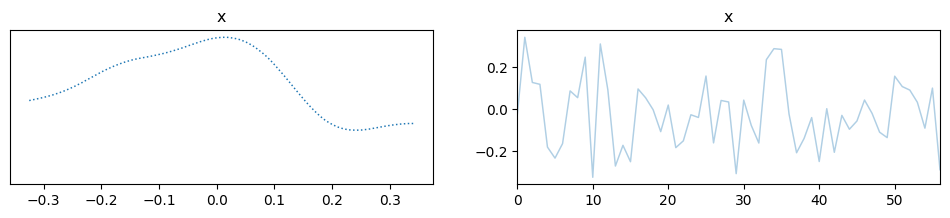

In [ ]:
az.plot_trace(beta_gk, combined=True)


In [ ]:
# Suppose your player data
X_data_def = X_def_pca.copy()

# Now fit!
beta_def = dirichlet_regression_beta_auto(X_data_def)

Number of Players: 2387, Number of Features: 61


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 4541 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Estimated β values:
 [-0.12473296  0.44896101  0.23086828  0.09719553 -0.34191065 -0.34364867
 -0.44355178  0.36488057  0.10172111  0.20619562 -0.47989808  0.47182711
  0.3344188  -0.27786476 -0.31475493 -0.32138833 -0.16837914  0.03152357
 -0.06429296 -0.19442363  0.12196926 -0.35140637 -0.20453345 -0.13057763
 -0.04723974  0.2860355  -0.29790017  0.0126047   0.09362832 -0.45325229
  0.10886158 -0.32948819 -0.43394376  0.44971151  0.46610667  0.30372108
 -0.19574982 -0.39830451  0.181392   -0.05617908 -0.372594    0.00302027
 -0.4633536   0.40441465 -0.23482974  0.15597403 -0.18278595  0.00700542
  0.05002225 -0.30848098  0.47767554  0.31021184  0.42214138  0.37489275
  0.0669946   0.42023824 -0.40608814 -0.30901024 -0.45723741 -0.17566766
 -0.10932542]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

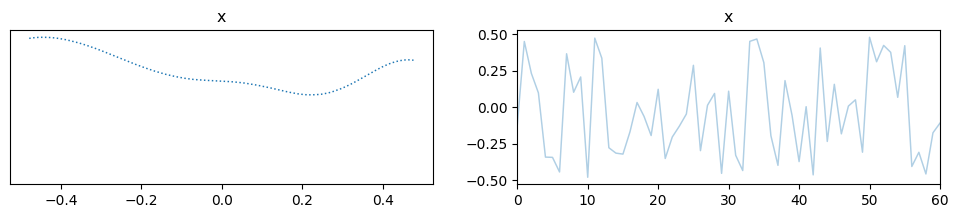

In [ ]:
az.plot_trace(beta_def, combined=True)

In [ ]:
# Suppose your player data
X_data_mid = X_mid_pca.copy()

# Now fit!
beta_mid = dirichlet_regression_beta_auto(X_data_mid)

Number of Players: 3823, Number of Features: 61


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 335 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Estimated β values:
 [-0.00989566  0.07540877  0.03638451  0.01806952 -0.05453228 -0.04845466
 -0.06739408  0.05659586  0.01263657  0.04787653 -0.06261978  0.07919525
  0.07660608 -0.03002599 -0.03830577 -0.03355508 -0.02062431 -0.00124973
  0.00618861 -0.02252741  0.01948746 -0.05524859 -0.0300683  -0.01678245
 -0.02014197  0.04744001 -0.03218017  0.00056715  0.02573497 -0.05888903
  0.01982475 -0.03726061 -0.06924565  0.05989528  0.08326342  0.06334788
 -0.02449428 -0.06213792  0.01474473 -0.00375474 -0.06658823  0.01030136
 -0.07914244  0.06959914 -0.04476365  0.03991738 -0.03109958  0.00264321
 -0.00136679 -0.0469186   0.07828436  0.0437845   0.06517927  0.07038258
  0.01186104  0.05359799 -0.07095348 -0.05049436 -0.06427832 -0.03633823
 -0.02070412]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

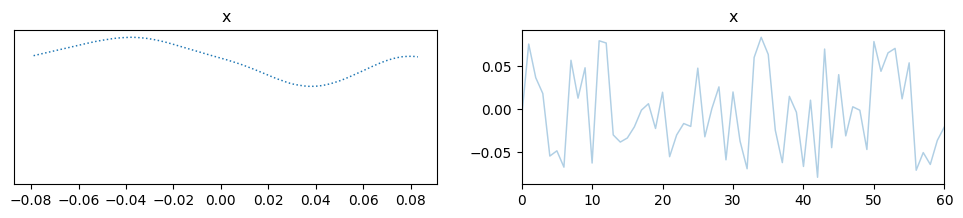

In [ ]:
az.plot_trace(beta_mid, combined=True)

In [ ]:
# Suppose your player data
X_data_fwd = X_fwd_pca.copy()
X_data_fwd = X_data_fwd.fillna(0)

# Now fit!
beta_fwd = dirichlet_regression_beta_auto(X_data_fwd)


Number of Players: 863, Number of Features: 59


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 2000 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Estimated β values:
 [-0.12282016  0.43671138  0.22640356  0.12465546 -0.33865539 -0.3013634
 -0.43103725  0.32792137  0.09890325  0.20710724 -0.42036749  0.42509968
  0.4319404  -0.26919757 -0.1235595  -0.15722831 -0.16425689  0.04973179
 -0.10065143 -0.11413411  0.22935446 -0.34727289 -0.20370143 -0.14465582
 -0.05787551  0.28587403 -0.28945621  0.04313695  0.10833704 -0.43339687
  0.18127275 -0.34424501 -0.29641787  0.44284763  0.46691414  0.27023369
 -0.1562986  -0.45613351  0.18284047 -0.02986663 -0.31933307  0.00162939
 -0.40600937  0.41276393 -0.25321257  0.16377815 -0.14070101  0.04764474
  0.0609128  -0.33286547  0.44602085  0.30581497  0.44435783  0.38965801
  0.08136898  0.41809111 -0.40755054 -0.31509898 -0.44856606]


array([[<Axes: title={'center': 'x'}>, <Axes: title={'center': 'x'}>]],
      dtype=object)

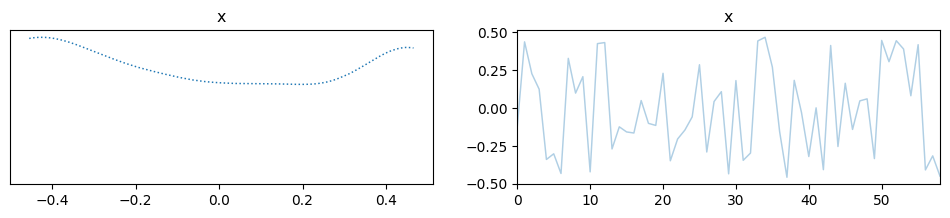

In [ ]:
az.plot_trace(beta_fwd, combined=True)

In [ ]:
 # Convert to pandas DataFrame
pd.DataFrame({
    "gk": beta_gk
}).to_csv('./gk_beta.csv', index=False)

pd.DataFrame({
    "def": beta_def
}).to_csv('./def_beta.csv', index=False)

pd.DataFrame({
    "mid": beta_mid
}).to_csv('./mid_beta.csv', index=False)

pd.DataFrame({
    "fwd": beta_fwd
}).to_csv('./fwd_beta.csv', index=False)